# Robust Accelerometer Pipeline with Hyperparameter Tuning

This notebook enhances the previous accelerometer data processing pipeline by incorporating hyperparameter optimization using the `optuna` library. The goal is to find the best combination of data preprocessing parameters (window size, purity threshold) and model hyperparameters for several deep learning models.

In [1]:
import os
import pandas as pd 
import tempfile 
import zipfile
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import confusion_matrix, precision_recall_fscore_support, accuracy_score, f1_score
from scipy.signal import butter, filtfilt
import matplotlib.pyplot as plt
import seaborn as sns
import copy
import warnings
import optuna
from optuna.visualization import plot_optimization_history, plot_param_importances

warnings.filterwarnings("ignore")

device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "mps" if torch.backends.mps.is_available()
    else "cpu")
print(f"Using device: {device}")

/home/rajesh/work/basic_stat/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using device: cuda


## 1. Data Loading and Initial Processing
First, we load the accelerometer data from the zip files, concatenate them, and perform a simple cleaning of the behavioral labels.

In [2]:
actual_file = []
#main_path = "/home/rajesh/work/acclerometer_project/zip_data"
main_path="/mnt/c/Users/rajes/Desktop/cortland"
if os.path.exists(main_path):
    for zip_file in os.listdir(main_path):
        if zip_file.endswith(".zip"):
            with tempfile.TemporaryDirectory() as temp_dir:
                try:
                    with zipfile.ZipFile(os.path.join(main_path, zip_file), "r") as zf:
                        zf.extractall(temp_dir)
                        for root, dirs, files in os.walk(temp_dir):
                            for d in dirs:
                                if d.startswith('Processed'):
                                    sec_path = os.path.join(root, d)
                                    for f in os.listdir(sec_path):
                                        if f.endswith((".xls", ".xlsx")):
                                            actual_file.append(pd.read_excel(os.path.join(sec_path, f)))
                except Exception as e: print(f"Error: {e}")
    if actual_file: 
        df_raw = pd.concat(actual_file)
    #     df_raw['behavioral_category']= df_raw['behavioral_category'].apply(lambda x : 'Resting' if x=='Resting Ruminating' else x)
    #     print("Data loaded and cleaned successfully.")
    #     print("Unique behaviors:", df_raw['behavioral_category'].unique())
    # else:
    #     print("No data loaded. Please check the path.")

map_dict={'Standing and Ruminating': 'Standing', 'Drinking':'Standing', 'Lying and Ruminating':'Lying', 'Browsing':'Grazing'}
type(list(map_dict.keys()))
df_raw['behavioral_category']= df_raw['behavioral_category'].apply(lambda x : map_dict[x] if x in list(map_dict.keys()) else x)
df_raw= df_raw[df_raw['behavioral_category']!='GreenFeed']

In [3]:
df_raw.columns

Index(['UTCdate', 'local_ts', 'x', 'y', 'z', 'subject', 'behavioral_category',
       'behavior_type'],
      dtype='object')

## 2. Pipeline, Models, and Training Functions
We define the data processing pipeline, the neural network models, and the Leave-One-Subject-Out (LOSO) training functions. A new function, `run_loso_for_tuning`, is created to accept hyperparameters, making it suitable for optimization with Optuna.

In [4]:
class AdaptiveAccelPipeline:
    def __init__(self, df):
        self.df = df.copy()
        self.df["local_ts"] = pd.to_datetime(self.df["local_ts"])
        self.df = self.df.sort_values(["subject", "local_ts"])

    def filter(self, cutoff=5.0):
        def f(g):
            dt = g["local_ts"].diff().dt.total_seconds()
            dt = dt[dt > 0]
            if len(dt) < 10:
                return g
            fs = 1 / dt.median()
            if fs <= cutoff * 2:
                return g
            nyq = fs * 0.5
            b, a = butter(4, cutoff / nyq, btype="low")
            for c in ["x", "y", "z"]:
                g[c] = filtfilt(b, a, g[c])
            return g
        self.df = self.df.groupby("subject", group_keys=False).apply(f)

    def features(self):
        scale = 16384
        self.df["x_g"] = self.df["x"] / scale
        self.df["y_g"] = self.df["y"] / scale
        self.df["z_g"] = self.df["z"] / scale
        self.df["mag"] = np.sqrt(self.df["x_g"]**2 + self.df["y_g"]**2 + self.df["z_g"]**2)
        self.df["enmo"] = np.maximum(self.df["mag"] - 1, 0)
        self.df["odba"] = ((self.df["x_g"] - self.df["x_g"] .mean()).abs() + (self.df["y_g"] - self.df["y_g"] .mean()).abs() + (self.df["z_g"] - self.df["z_g"] .mean()).abs())

    def resample(self, window=10, thresh=0.7):
        def labeler(x):
            vc = x.value_counts(normalize=True)
            if len(vc) and vc.iloc[0] >= thresh:
                return vc.index[0]
            return np.nan

        agg = {
            "x_g": ["mean", "std"], "y_g": ["mean", "std"], "z_g": ["mean", "std"],
            "mag": ["mean", "std"], "enmo": ["mean", "max"], "odba": ["mean", "std"],
            "behavioral_category": labeler
        }
        out = self.df.set_index("local_ts").groupby("subject").resample(f"{window}s").agg(agg)
        out.columns = [f"{a}_{b}" if b else a for a, b in out.columns]
        out = out.rename(columns={"behavioral_category_labeler": "label"})
        return out.dropna(subset=["label"]).reset_index()

    def sequences(self, df, feats, target, steps):
        X, y, s = [], [], []
        for sub, g in df.groupby("subject"):
            g = g.sort_values("local_ts")
            if len(g) <= steps:
                continue
            for i in range(len(g) - steps):
                X.append(g[feats].values[i:i+steps])
                y.append(g[target].iloc[i+steps])
                s.append(sub)
        return np.array(X), np.array(y), np.array(s)

# --- Models --- 
class RNNModel(nn.Module):
    def __init__(self, input_dim, hidden_dim, classes):
        super().__init__()
        self.rnn = nn.RNN(input_dim, hidden_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, classes)
    def forward(self, x):
        out, _ = self.rnn(x)
        return self.fc(out[:, -1, :])

class LSTMModel(nn.Module):
    def __init__(self, input_dim, hidden_dim, classes):
        super().__init__()
        self.lstm = nn.LSTM(input_dim, hidden_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, classes)
    def forward(self, x):
        out, _ = self.lstm(x)
        return self.fc(out[:, -1, :])

class BiLSTMModel(nn.Module):
    def __init__(self, input_dim, hidden_dim, classes):
        super().__init__()
        self.lstm = nn.LSTM(input_dim, hidden_dim, batch_first=True, bidirectional=True)
        self.fc = nn.Linear(hidden_dim * 2, classes)
    def forward(self, x):
        out, _ = self.lstm(x)
        return self.fc(out[:, -1, :])

# --- LOSO Training Function for Optuna --- 
def run_loso_for_tuning(X, y, subjects, le, model_type, params):
    all_true, all_pred = [], []
    unique_subjects = np.unique(subjects)

    for test_subject in unique_subjects:
        tr = subjects != test_subject
        te = subjects == test_subject
        Xtr, Xte, ytr, yte = X[tr], X[te], y[tr], y[te]

        if len(np.unique(ytr)) < 2: continue

        train_loader = DataLoader(TensorDataset(torch.tensor(Xtr).float(), torch.tensor(ytr)), batch_size=32, shuffle=True)
        test_loader = DataLoader(TensorDataset(torch.tensor(Xte).float(), torch.tensor(yte)), batch_size=32)

        input_dim = X.shape[2]
        num_classes = len(le.classes_)
        
        if model_type == "RNN": model = RNNModel(input_dim, params['hidden_dim'], num_classes)
        elif model_type == "LSTM": model = LSTMModel(input_dim, params['hidden_dim'], num_classes)
        elif model_type == "BiLSTM": model = BiLSTMModel(input_dim, params['hidden_dim'], num_classes)
        
        model.to(device)
        opt = optim.Adam(model.parameters(), lr=params['lr'])
        loss_fn = nn.CrossEntropyLoss()

        for epoch in range(15):
            model.train()
            for xb, yb in train_loader:
                xb, yb = xb.to(device), yb.to(device)
                opt.zero_grad()
                loss = loss_fn(model(xb), yb)
                loss.backward()
                opt.step()

        model.eval()
        preds = []
        with torch.no_grad():
            for xb, _ in test_loader:
                preds.extend(torch.argmax(model(xb.to(device)), 1).cpu().numpy())
        all_true.extend(yte)
        all_pred.extend(preds)

    return np.array(all_true), np.array(all_pred)

In [21]:
pipe = AdaptiveAccelPipeline(df_raw)
pipe.filter()
pipe.features()
df_r = pipe.resample(window=10, thresh=0.8)

In [24]:
df_r['subject']

0         500
1         500
2         500
3         500
4         500
         ... 
18512    1144
18513    1144
18514    1144
18515    1144
18516    1144
Name: subject, Length: 18517, dtype: int64

In [ ]:
# =====================================================
# IMPORTS
# =====================================================
import os
import csv
import copy
import warnings
from collections import Counter

import numpy as np
import pandas as pd
import optuna

# Scikit-Learn / Classical ML
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
import xgboost as xgb

# PyTorch / Deep Learning
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from scipy.signal import butter, filtfilt

# Suppress warnings for cleaner output
warnings.filterwarnings("ignore")

# Set device
device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "mps" if torch.backends.mps.is_available()
    else "cpu"
)

# ==========================================================
# 1. PIPELINE & PYTORCH MODELS
# ==========================================================
class AdaptiveAccelPipeline:
    def __init__(self, df):
        self.df = df.copy()
        self.df["local_ts"] = pd.to_datetime(self.df["local_ts"])
        self.df = self.df.sort_values(["subject", "local_ts"])

    def filter(self, cutoff=5.0):
        def f(g):
            dt = g["local_ts"].diff().dt.total_seconds()
            dt = dt[dt > 0]
            if len(dt) < 10:
                return g
            fs = 1 / dt.median()
            nyq = fs * 0.5
            if fs <= cutoff * 2:
                return g
            b, a = butter(4, cutoff / nyq, btype="low")
            for c in ["x", "y", "z"]:
                g[c] = filtfilt(b, a, g[c])
            return g
        self.df = self.df.groupby("subject", group_keys=False).apply(f)

    def features(self):
        scale = 16384
        self.df["x_g"] = self.df["x"] / scale
        self.df["y_g"] = self.df["y"] / scale
        self.df["z_g"] = self.df["z"] / scale
        self.df["mag"] = np.sqrt(
            self.df["x_g"]**2 + self.df["y_g"]**2 + self.df["z_g"]**2
        )
        self.df["enmo"] = np.maximum(self.df["mag"] - 1, 0)
        self.df["odba"] = (
            (self.df["x_g"] - self.df["x_g"].mean()).abs() +
            (self.df["y_g"] - self.df["y_g"].mean()).abs() +
            (self.df["z_g"] - self.df["z_g"].mean()).abs()
        )

    def resample(self, window=10, thresh=0.7):
        def labeler(x):
            vc = x.value_counts(normalize=True)
            if len(vc) and vc.iloc[0] >= thresh:
                return vc.index[0]
            return np.nan

        agg = {
            "x_g": ["mean", "std"],
            "y_g": ["mean", "std"],
            "z_g": ["mean", "std"],
            "mag": ["mean", "std"],
            "enmo": ["mean", "max"],
            "odba": ["mean", "std"],
            "behavioral_category": labeler
        }

        out = (
            self.df.set_index("local_ts")
            .groupby("subject")
            .resample(f"{window}s")
            .agg(agg)
        )

        out.columns = [f"{a}_{b}" if b else a for a, b in out.columns]
        out = out.rename(columns={"behavioral_category_labeler": "label"})
        return out.dropna(subset=["label"]).reset_index()

    def sequences(self, df, feats, target, steps):
        X, y, s = [], [], []
        for sub, g in df.groupby("subject"):
            g = g.sort_values("local_ts")
            if len(g) <= steps:
                continue
            for i in range(len(g) - steps):
                X.append(g[feats].values[i:i+steps])
                y.append(g[target].iloc[i+steps])
                s.append(sub)
        return np.array(X), np.array(y), np.array(s)

class RNNModel(nn.Module):
    def __init__(self, input_dim, hidden_dim, classes):
        super().__init__()
        self.rnn = nn.RNN(input_dim, hidden_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, classes)

    def forward(self, x):
        out, _ = self.rnn(x)
        return self.fc(out[:, -1, :])

class LSTMModel(nn.Module):
    def __init__(self, input_dim, hidden_dim, classes):
        super().__init__()
        self.lstm = nn.LSTM(input_dim, hidden_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, classes)

    def forward(self, x):
        out, _ = self.lstm(x)
        return self.fc(out[:, -1, :])

class BiLSTMModel(nn.Module):
    def __init__(self, input_dim, hidden_dim, classes):
        super().__init__()
        self.lstm = nn.LSTM(input_dim, hidden_dim, batch_first=True, bidirectional=True)
        self.fc = nn.Linear(hidden_dim * 2, classes)

    def forward(self, x):
        out, _ = self.lstm(x)
        return self.fc(out[:, -1, :])

class TransformerModel(nn.Module):
    def __init__(self, input_dim, heads, layers, classes):
        super().__init__()
        enc = nn.TransformerEncoderLayer(d_model=input_dim, nhead=heads, batch_first=True)
        self.encoder = nn.TransformerEncoder(enc, layers)
        self.fc = nn.Linear(input_dim, classes)

    def forward(self, x):
        x = self.encoder(x)
        return self.fc(x[:, -1, :])

# ==========================================================
# 2. CSV LOGGING SETUP
# ==========================================================
CSV_FILE = "optuna_loso_results.csv"
CSV_HEADERS = [
    "trial_number", "model_family", "model_type", "feature_set",
    "window", "thresh", "steps",
    "rf_n_estimators", "rf_max_depth",
    "xgb_n_estimators", "xgb_lr", "xgb_max_depth",
    "svm_C", "svm_kernel",
    "nb_var_smoothing",
    "ts_hidden_dim", "ts_lr", "ts_batch_size",
    "avg_accuracy", "avg_precision", "avg_recall", "avg_f1_macro",
    "pooled_test_distribution"
]

if not os.path.exists(CSV_FILE):
    with open(CSV_FILE, mode='w', newline='') as f:
        writer = csv.writer(f)
        writer.writerow(CSV_HEADERS)

FEATURE_COMBINATIONS = {
    "all_features": ['x_g_mean', 'x_g_std', 'y_g_mean', 'y_g_std', 'z_g_mean', 'z_g_std', 'mag_mean', 'mag_std', 'enmo_mean', 'enmo_max', 'odba_mean', 'odba_std'],
    "base_features": ['x_g_mean', 'x_g_std', 'y_g_mean', 'y_g_std', 'z_g_mean', 'z_g_std', 'mag_mean', 'mag_std'],
    "base_plus_enmo": ['x_g_mean', 'x_g_std', 'y_g_mean', 'y_g_std', 'z_g_mean', 'z_g_std', 'mag_mean', 'mag_std', 'enmo_mean', 'enmo_max']
}

# ==========================================================
# 3. OPTUNA OBJECTIVE FUNCTION
# ==========================================================
def objective(trial):
    trial_data = {key: "" for key in CSV_HEADERS}
    trial_data["trial_number"] = trial.number
    
    # --- A. Data Processing & Feature Hyperparameters ---
    window = trial.suggest_int("window", 10, 30, step=5)
    thresh = trial.suggest_float("thresh", 0.6, 0.8, step=0.05)
    feature_set_name = trial.suggest_categorical("feature_set", list(FEATURE_COMBINATIONS.keys()))
    selected_features = FEATURE_COMBINATIONS[feature_set_name]
    
    trial_data["window"] = window
    trial_data["thresh"] = thresh
    trial_data["feature_set"] = feature_set_name
    
    # --- B. Model Family Selection ---
    model_family = trial.suggest_categorical("model_family", ["Classical", "TimeSeries"])
    trial_data["model_family"] = model_family

    model_type = ""
    steps = ""
    
    # --- C. Hyperparameter Suggestion Branching ---
    if model_family == "Classical":
        model_type = trial.suggest_categorical("model_type_classical", ["RF", "XGBoost", "SVM", "NB"])
        
        if model_type == "RF":
            trial_data["rf_n_estimators"] = trial.suggest_int("rf_n_estimators", 50, 300, step=50)
            trial_data["rf_max_depth"] = trial.suggest_int("rf_max_depth", 3, 20)
        elif model_type == "XGBoost":
            trial_data["xgb_n_estimators"] = trial.suggest_int("xgb_n_estimators", 50, 300, step=50)
            trial_data["xgb_lr"] = trial.suggest_float("xgb_lr", 1e-3, 0.3, log=True)
            trial_data["xgb_max_depth"] = trial.suggest_int("xgb_max_depth", 3, 10)
        elif model_type == "SVM":
            trial_data["svm_C"] = trial.suggest_float("svm_C", 1e-3, 100, log=True)
            trial_data["svm_kernel"] = trial.suggest_categorical("svm_kernel", ["linear", "rbf"])
        elif model_type == "NB":
            trial_data["nb_var_smoothing"] = trial.suggest_float("nb_var_smoothing", 1e-10, 1e-8, log=True)
            
    else: # TimeSeries
        model_type = trial.suggest_categorical("model_type_ts", ["RNN", "LSTM", "BiLSTM", "Transformer"])
        steps = trial.suggest_int("steps", 5, 20, step=5)
        trial_data["steps"] = steps
        trial_data["ts_hidden_dim"] = trial.suggest_categorical("ts_hidden_dim", [32, 64, 128])
        trial_data["ts_lr"] = trial.suggest_float("ts_lr", 1e-4, 1e-2, log=True)
        trial_data["ts_batch_size"] = trial.suggest_categorical("ts_batch_size", [16, 32, 64])

    trial_data["model_type"] = model_type

    # ==========================================================
    # 4. DATA PREPARATION PIPELINE
    # ==========================================================
    pipe = AdaptiveAccelPipeline(df_raw) # Requires df_raw globally
    pipe.filter()
    pipe.features()
    df_r = pipe.resample(window=window, thresh=thresh)
    
    # Prune if the aggressive resampling wiped out too much data
    if df_r.empty or df_r['subject'].nunique() < 2:
        raise optuna.exceptions.TrialPruned()

    le = LabelEncoder()
    df_r["label_enc"] = le.fit_transform(df_r["label"])
    
    scaler = StandardScaler()
    df_r[selected_features] = scaler.fit_transform(df_r[selected_features])

    # Branching Data Organization: 2D vs 3D
    if model_family == "Classical":
        X = df_r[selected_features].values
        y = df_r["label_enc"].values
        subjects = df_r["subject"].values
    else:
        X, y, subjects = pipe.sequences(df_r, selected_features, "label_enc", steps=steps)
        if len(X) == 0:
            raise optuna.exceptions.TrialPruned()

    # ==========================================================
    # 5. LEAVE-ONE-SUBJECT-OUT (LOSO) CROSS-VALIDATION
    # ==========================================================
    unique_subjects = np.unique(subjects)
    fold_accuracies, fold_precisions, fold_recalls, fold_f1s = [], [], [], []
    pooled_test_distributions = Counter()

    for test_subject in unique_subjects:
        # Create Boolean Masks
        tr_mask = subjects != test_subject
        te_mask = subjects == test_subject
        
        Xtr, Xte = X[tr_mask], X[te_mask]
        ytr, yte = y[tr_mask], y[te_mask]
        
        # Skip if training data lacks multiple classes
        if len(np.unique(ytr)) < 2:
            continue 
            
        pooled_test_distributions.update(yte)

        # --------------------------------------------------
        # Branch 5A: Classical Model Training
        # --------------------------------------------------
        if model_family == "Classical":
            if model_type == "RF":
                model = RandomForestClassifier(n_estimators=trial_data["rf_n_estimators"], max_depth=trial_data["rf_max_depth"])
            elif model_type == "XGBoost":
                model = xgb.XGBClassifier(n_estimators=trial_data["xgb_n_estimators"], learning_rate=trial_data["xgb_lr"], max_depth=trial_data["xgb_max_depth"])
            elif model_type == "SVM":
                model = SVC(C=trial_data["svm_C"], kernel=trial_data["svm_kernel"])
            elif model_type == "NB":
                model = GaussianNB(var_smoothing=trial_data["nb_var_smoothing"])
                
            model.fit(Xtr, ytr)
            preds = model.predict(Xte)

        # --------------------------------------------------
        # Branch 5B: Deep Learning PyTorch Training
        # --------------------------------------------------
        else:
            batch_size = trial_data["ts_batch_size"]
            
            # Use .long() strictly for CrossEntropyLoss
            train_loader = DataLoader(
                TensorDataset(torch.tensor(Xtr).float(), torch.tensor(ytr).long()), 
                batch_size=batch_size, shuffle=True
            )
            test_loader = DataLoader(
                TensorDataset(torch.tensor(Xte).float(), torch.tensor(yte).long()), 
                batch_size=batch_size
            )
            
            input_dim = X.shape[2]
            num_classes = len(np.unique(y))
            hidden_dim = trial_data["ts_hidden_dim"]
            
            if model_type == "RNN":
                model = RNNModel(input_dim, hidden_dim, num_classes)
            elif model_type == "LSTM":
                model = LSTMModel(input_dim, hidden_dim, num_classes)
            elif model_type == "BiLSTM":
                model = BiLSTMModel(input_dim, hidden_dim, num_classes)
            elif model_type == "Transformer":
                model = TransformerModel(input_dim, heads=2, layers=2, classes=num_classes)
                
            model.to(device)
            
            opt = optim.Adam(model.parameters(), lr=trial_data["ts_lr"])
            loss_fn = nn.CrossEntropyLoss()
            
            best_loss = np.inf
            best_wts = copy.deepcopy(model.state_dict())
            patience, p = 5, 0
            
            # PyTorch Loop
            for epoch in range(15): 
                model.train()
                for xb, yb in train_loader:
                    xb, yb = xb.to(device), yb.to(device)
                    opt.zero_grad()
                    logits = model(xb) 
                    loss = loss_fn(logits, yb)
                    loss.backward()
                    opt.step()
                
                # Validation Hold-Out Test Subject
                model.eval()
                val_loss = 0
                with torch.no_grad():
                    for xb, yb in test_loader:
                        xb, yb = xb.to(device), yb.to(device)
                        logits = model(xb)
                        val_loss += loss_fn(logits, yb).item()
                        
                if val_loss < best_loss:
                    best_loss = val_loss
                    best_wts = copy.deepcopy(model.state_dict())
                    p = 0
                else:
                    p += 1
                    if p >= patience: 
                        break
                        
            # Test Execution
            model.load_state_dict(best_wts)
            model.eval()
            preds = []
            with torch.no_grad():
                for xb, _ in test_loader:
                    xb = xb.to(device)
                    logits = model(xb)
                    preds.extend(torch.argmax(logits, 1).cpu().numpy())
            preds = np.array(preds)

        # --------------------------------------------------
        # Metric Calculation per Subject Fold
        # --------------------------------------------------
        acc = accuracy_score(yte, preds)
        prec, rec, f1, _ = precision_recall_fscore_support(yte, preds, average='macro', zero_division=0)
        
        fold_accuracies.append(acc)
        fold_precisions.append(prec)
        fold_recalls.append(rec)
        fold_f1s.append(f1)

    # ==========================================================
    # 6. AGGREGATE AND LOG RESULTS
    # ==========================================================
    avg_f1_macro = np.mean(fold_f1s) if fold_f1s else 0
    
    trial_data["avg_accuracy"] = round(np.mean(fold_accuracies), 4) if fold_accuracies else 0
    trial_data["avg_precision"] = round(np.mean(fold_precisions), 4) if fold_precisions else 0
    trial_data["avg_recall"] = round(np.mean(fold_recalls), 4) if fold_recalls else 0
    trial_data["avg_f1_macro"] = round(avg_f1_macro, 4)
    trial_data["pooled_test_distribution"] = str(dict(pooled_test_distributions))
    
    # Optuna User Attributes
    for key, value in trial_data.items():
        if value != "": trial.set_user_attr(key, value)
            
    # Write directly to CSV
    with open(CSV_FILE, mode='a', newline='') as f:
        writer = csv.writer(f)
        writer.writerow([trial_data[col] for col in CSV_HEADERS])
        
    return avg_f1_macro

# ==========================================================
# MAIN EXECUTION
# ==========================================================
if __name__ == "__main__":
    # Ensure you have loaded your dataframe globally as `df_raw` before this runs!
    # Example: df_raw = pd.read_csv("your_data.csv")
    
    study = optuna.create_study(direction="maximize", study_name="Unified_ML_DL_LOSO")
    study.optimize(objective, n_trials=500)
    
    print(f"Optimization finished. All runs logged live to {CSV_FILE}")

[I 2026-02-23 08:53:25,968] A new study created in memory with name: Unified_ML_DL_LOSO
[I 2026-02-23 08:55:04,109] Trial 0 finished with value: 0.6142296095294458 and parameters: {'window': 20, 'thresh': 0.75, 'feature_set': 'all_features', 'model_family': 'TimeSeries', 'model_type_ts': 'Transformer', 'steps': 20, 'ts_hidden_dim': 32, 'ts_lr': 0.0035827976520860015, 'ts_batch_size': 64}. Best is trial 0 with value: 0.6142296095294458.
[I 2026-02-23 09:02:03,419] Trial 1 finished with value: 0.6294130534852612 and parameters: {'window': 10, 'thresh': 0.7, 'feature_set': 'base_plus_enmo', 'model_family': 'TimeSeries', 'model_type_ts': 'Transformer', 'steps': 5, 'ts_hidden_dim': 128, 'ts_lr': 0.0008887831637245289, 'ts_batch_size': 32}. Best is trial 1 with value: 0.6294130534852612.
[I 2026-02-23 09:03:26,922] Trial 2 finished with value: 0.5096895350278966 and parameters: {'window': 10, 'thresh': 0.65, 'feature_set': 'base_plus_enmo', 'model_family': 'Classical', 'model_type_classical'

In [28]:
os.listdir()

['experiment_engine.py',
 'data_io.py',
 'optuna_loso_results.csv',
 '.git',
 'accel_pipeline.py',
 'methodology.ipynb',
 'time_series_1_9.py',
 'slurm_pipeline.ipynb',
 'results',
 'models.py',
 'README.md',
 'timeseries_results.csv',
 'timeseries_models.py',
 'time_series.py',
 'processing_with_torch.ipynb',
 'pytorch_results.csv',
 'main.py',
 'time_series_utils.py',
 'initial_results.csv',
 'methodology.py',
 '__pycache__',
 'processing_ts_1_26.ipynb',
 'robust_accelerometer_pipeline.ipynb',
 'processing.ipynb',
 'combine_processing.ipynb',
 'test_model.py',
 'run_experiments.ipynb',
 'feature_pipeline.py',
 'final_combined_results.csv',
 'methods_codes',
 'processing_with_ts.ipynb',
 'modeling_utils.py',
 'pipeline_utils.py']

In [14]:
pipe= AdaptiveAccelPipeline(df_raw)

In [15]:
pipe

df_r.columns

## 3. Optuna Objective Function
This function defines the search space for our hyperparameters. For each trial, Optuna selects a combination of parameters, and we run the entire data processing and training pipeline to evaluate its performance (F1-score).

In [6]:
def objective(trial, model_type):
    # 1. Suggest data processing hyperparameters
    window = trial.suggest_int("window", 10, 30, step=5)
    thresh = trial.suggest_float("thresh", 0.6, 0.8, step=0.05)
    steps = trial.suggest_int("steps", 5, 20, step=5)

    # 2. Suggest model hyperparameters
    params = {
        'hidden_dim': trial.suggest_categorical("hidden_dim", [32, 64, 128]),
        'lr': trial.suggest_float("lr", 1e-4, 1e-2, log=True)
    }

    # 3. Run the pipeline with suggested params
    pipe = AdaptiveAccelPipeline(df_raw)
    pipe.filter()
    pipe.features()
    df_r = pipe.resample(window=window, thresh=thresh)

    if len(df_r) < 100: # Not enough data to form sequences
        return 0.0 # Prune trial

    feats = [c for c in df_r.columns if c not in ["subject", "local_ts", "label"] ]
    le = LabelEncoder()
    df_r["label_enc"] = le.fit_transform(df_r["label"])
    df_r[feats] = StandardScaler().fit_transform(df_r[feats])

    X, y, subjects = pipe.sequences(df_r, feats, "label_enc", steps=steps)

    if X.shape[0] == 0: # Check if sequences were created
        return 0.0
    
    # 4. Train and evaluate
    y_true, y_pred = run_loso_for_tuning(X, y, subjects, le, model_type, params)

    # 5. Return the F1 score for Optuna to maximize
    return f1_score(y_true, y_pred, average='macro', zero_division=0)

## 4. Hyperparameter Tuning Execution
We now run the optimization studies. We'll do this for a few models (e.g., LSTM and BiLSTM) for a set number of trials. For a real-world scenario, `n_trials` should be much higher (e.g., 50-100).

In [ ]:
models_to_tune = ["LSTM", "BiLSTM"] # Add 'RNN' if desired
studies = {}

for model_name in models_to_tune:
    print(f"\n--- Tuning {model_name} ---")
    study = optuna.create_study(direction="maximize", pruner=optuna.pruners.MedianPruner())
    study.optimize(lambda trial: objective(trial, model_name), n_trials=20) # Using 20 trials for demonstration
    studies[model_name] = study
    
    print(f"--- Best Trial for {model_name} ---")
    print(f"  Value: {study.best_value:.4f}")
    print("  Params: ")
    for key, value in study.best_params.items():
        print(f"    {key}: {value}")

## 5. Visualizing Optimization Results
Optuna provides helpful visualizations to understand the search process.

In [8]:
for model_name, study in studies.items():
    print(f"\n--- Optuna Plots for {model_name} ---")
    # Plot 1: Optimization History
    fig1 = plot_optimization_history(study)
    fig1.update_layout(title=f'{model_name} Optimization History')
    fig1.show()
    
    # Plot 2: Parameter Importances
    try:
        fig2 = plot_param_importances(study)
        fig2.update_layout(title=f'{model_name} Parameter Importances')
        fig2.show()
    except:
        print("Could not generate parameter importances plot (might need more completed trials).")


--- Optuna Plots for LSTM ---



--- Optuna Plots for BiLSTM ---


## 6. Final Validation with Best Hyperparameters
Finally, we take the best parameters found by Optuna for the top-performing model and run a full evaluation, including generating the detailed validation plots as requested.


--- Running Final Validation on Best Model: BiLSTM ---
Using best parameters: {'window': 10, 'thresh': 0.75, 'steps': 10, 'hidden_dim': 64, 'lr': 0.00010243598866164972}

Final Overall Results for BiLSTM:
  - Macro F1-Score: 0.6955
  - Accuracy: 0.8677


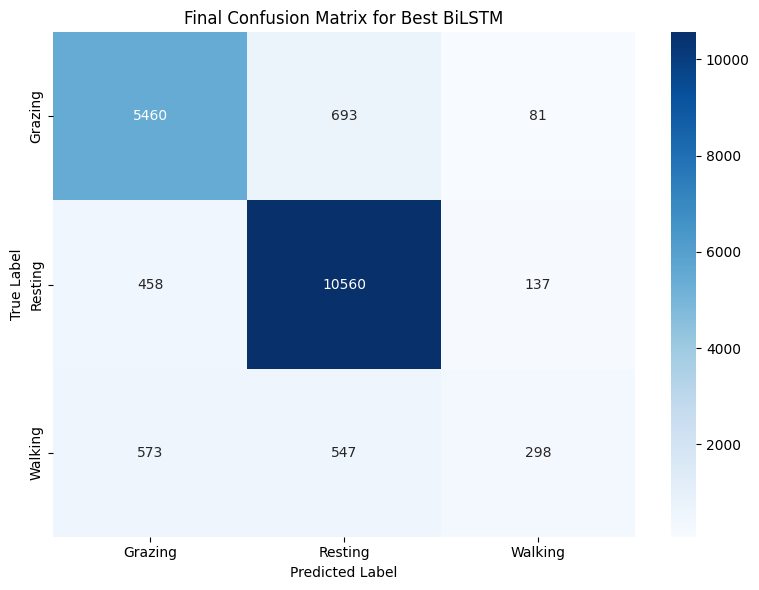

In [9]:
# Visualization functions from the original notebook (for the final evaluation)
def plot_aggregate_confusion(y_true, y_pred, le, title):
    cm = confusion_matrix(y_true, y_pred, labels=range(len(le.classes_)))
    plt.figure(figsize=(8,6))
    sns.heatmap(cm, annot=True, fmt="d", xticklabels=le.classes_, yticklabels=le.classes_, cmap="Blues")
    plt.title(title)
    plt.ylabel("True Label")
    plt.xlabel("Predicted Label")
    plt.tight_layout()
    plt.show()

# Find the best model among the studies
best_model_name = max(studies, key=lambda m: studies[m].best_value)
best_study = studies[best_model_name]
best_params = best_study.best_params

print(f"\n--- Running Final Validation on Best Model: {best_model_name} ---")
print("Using best parameters:", best_params)

# 1. Re-run pipeline with best data params
pipe = AdaptiveAccelPipeline(df_raw)
pipe.filter()
pipe.features()
df_r_best = pipe.resample(window=best_params['window'], thresh=best_params['thresh'])

feats = [c for c in df_r_best.columns if c not in ["subject", "local_ts", "label"] ]
le = LabelEncoder()
df_r_best["label_enc"] = le.fit_transform(df_r_best["label"])
df_r_best[feats] = StandardScaler().fit_transform(df_r_best[feats])
X, y, subjects = pipe.sequences(df_r_best, feats, "label_enc", steps=best_params['steps'])

# 2. Run LOSO with best model params
model_params = {'hidden_dim': best_params['hidden_dim'], 'lr': best_params['lr']}
y_true_final, y_pred_final = run_loso_for_tuning(X, y, subjects, le, best_model_name, model_params)

# 3. Display Final Validation Plot (Confusion Matrix)
print(f"\nFinal Overall Results for {best_model_name}:")
final_f1 = f1_score(y_true_final, y_pred_final, average='macro', zero_division=0)
final_acc = accuracy_score(y_true_final, y_pred_final)
print(f"  - Macro F1-Score: {final_f1:.4f}")
print(f"  - Accuracy: {final_acc:.4f}")

plot_aggregate_confusion(y_true_final, y_pred_final, le, f'Final Confusion Matrix for Best {best_model_name}')